In [4]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
sess = stx.utilities_ES.load_single_day(sparse_mice[0],0, pkl_basedir='/home/mplitt/YMazeSessPkls')

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}


In [26]:
sess.neuropil_corrected_dff_mux(channels = ('channel_0', 'channel_1'), sig_output = 3)

channel_0
207 5467
6711 11118
12945 16908
17856 22654
23619 28613
29554 38948
channel_1
206 5467
6710 11118
12944 16907
17856 22653
23619 28612
29553 38947


0.30112836687711114


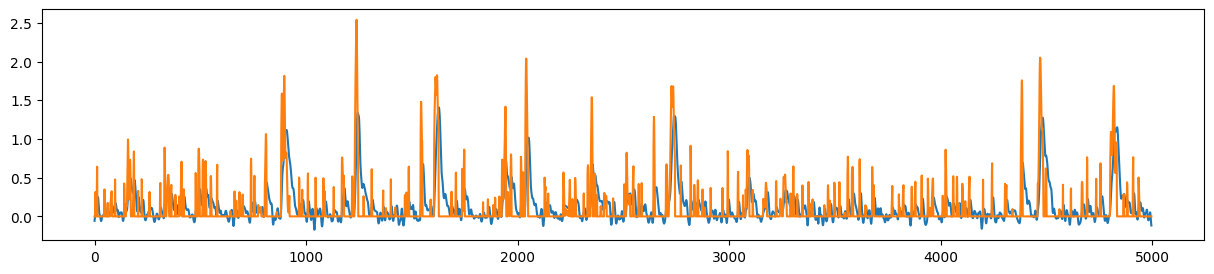

In [44]:
rng = np.random.default_rng()
fig, ax = plt.subplots(figsize=[15,3])

for cell in range(0,10,10):
    spks = sess.timeseries['channel_1_spks'][cell,:]*15.46
    dev = sp.stats.median_abs_deviation(sess.timeseries['channel_1_F_dff'][cell,:], nan_policy='omit')
    ax.plot(sess.timeseries['channel_1_F_dff'][cell,-5000:]+cell/10)
    ax.plot(sess.timeseries['channel_1_spks'][cell,-5000:]*15.46)
    print(dev*4)


In [28]:
dF_traces = sess.timeseries['channel_1_F_dff']
np.save('./sample_ch1_spks.npy',dF_traces)